# 03 — Preprocessing

Wildfires Susceptibility Mapping — Córdoba, Argentina  
Input: `data/processed/dataset.csv`  
Outputs: `data/processed/train.csv`, `data/processed/test.csv`, `data/processed/scaler.pkl`, `data/processed/encoder.pkl`, `data/processed/selected_features.json`

Pipeline:
1. Load data, impute missing values
2. VIF-based multicollinearity filter (threshold = 10)
3. Pairwise correlation filter (threshold |r| = 0.85)
4. One-hot encode `land_cover_class`
5. StandardScaler on continuous features
6. Stratified 70/30 train/test split
7. Save outputs

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', font_scale=1.1)

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

RANDOM_STATE = 42
VIF_THRESHOLD  = 10.0
CORR_THRESHOLD = 0.85
TEST_SIZE      = 0.30

df = pd.read_csv(PROCESSED / 'dataset.csv')
print(f'Loaded: {df.shape}')

Loaded: (72296, 24)


## 1. Missing Value Imputation

In [2]:
# Only population_density has NaN (~3.9%) — impute with median
pop_median = df['population_density'].median()
df['population_density'] = df['population_density'].fillna(pop_median)

print(f'population_density: filled {df["population_density"].isnull().sum()} NaN with median = {pop_median:.4f}')
assert df.isnull().sum().sum() == 0, 'Unexpected NaN remaining'
print('No remaining NaN values.')

population_density: filled 0 NaN with median = 0.8682
No remaining NaN values.


## 2. VIF-based Multicollinearity Filter

In [3]:
# Features to include in VIF (exclude identifiers, target, categorical, binary flags)
EXCLUDE_FROM_VIF = {'lat', 'lon', 'label', 'month', 'land_cover_class', 'fire_season_flag'}

def compute_vif(data: pd.DataFrame) -> pd.DataFrame:
    """Compute VIF for all columns in data."""
    vif_data = pd.DataFrame()
    vif_data['feature'] = data.columns
    vif_data['VIF'] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)


def iterative_vif_filter(df: pd.DataFrame, threshold: float) -> list:
    """
    Iteratively remove the feature with highest VIF > threshold.
    Returns list of kept feature names.
    """
    keep = [c for c in df.columns if c not in EXCLUDE_FROM_VIF]
    iteration = 0
    dropped = []
    
    while True:
        vif = compute_vif(df[keep])
        max_vif = vif['VIF'].max()
        if max_vif <= threshold:
            break
        worst = vif.loc[vif['VIF'].idxmax(), 'feature']
        print(f'  Iter {iteration+1}: drop "{worst}" (VIF={max_vif:.2f})')
        keep.remove(worst)
        dropped.append(worst)
        iteration += 1
    
    return keep, dropped


print(f'Starting VIF filter (threshold={VIF_THRESHOLD})...')
initial_numeric = [c for c in df.columns if c not in EXCLUDE_FROM_VIF]
print(f'Initial numeric features: {len(initial_numeric)} — {initial_numeric}')
print()

# Show initial VIF table
initial_vif = compute_vif(df[initial_numeric])
print('Initial VIF values:')
print(initial_vif.to_string(index=False))

Starting VIF filter (threshold=10.0)...
Initial numeric features: 18 — ['elevation', 'slope', 'aspect_cos', 'twi', 'ndvi', 'lst', 'temperature', 'precipitation', 'wind_speed', 'vpd', 'population_density', 'soc', 'clay', 'phh2o', 'bdod', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km']



Initial VIF values:
                  feature         VIF
              temperature 1639.457732
                      twi  613.971007
                     bdod  598.093919
                    phh2o  577.669843
                      vpd  489.094261
            precipitation  142.602833
                     ndvi   34.676592
                     clay   29.755702
               wind_speed   28.131030
                      lst   21.631718
                      soc   18.884627
distance_to_settlement_km   10.254424
                elevation    6.688405
      distance_to_road_km    4.003230
     distance_to_river_km    3.835053
                    slope    3.414154
       population_density    1.226962
               aspect_cos    1.204496


In [4]:
kept_features, dropped_vif = iterative_vif_filter(df, VIF_THRESHOLD)

print(f'\nDropped by VIF: {dropped_vif}')
print(f'Kept after VIF: {len(kept_features)} features — {kept_features}')

# Final VIF table
final_vif = compute_vif(df[kept_features])
print('\nFinal VIF table (all should be < 10):')
print(final_vif.to_string(index=False))
assert final_vif['VIF'].max() <= VIF_THRESHOLD, 'VIF filter failed'

  Iter 1: drop "temperature" (VIF=1639.46)


  Iter 2: drop "phh2o" (VIF=576.49)


  Iter 3: drop "twi" (VIF=345.57)


  Iter 4: drop "bdod" (VIF=59.93)


  Iter 5: drop "vpd" (VIF=30.87)


...

  Iter 7: drop "ndvi" (VIF=19.06)


  Iter 8: drop "soc" (VIF=15.29)


  Iter 9: drop "wind_speed" (VIF=13.67)



Dropped by VIF: ['temperature', 'phh2o', 'twi', 'bdod', 'vpd', 'precipitation', 'ndvi', 'soc', 'wind_speed']
Kept after VIF: 9 features — ['elevation', 'slope', 'aspect_cos', 'lst', 'population_density', 'clay', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km']



Final VIF table (all should be < 10):
                  feature      VIF
                      lst 8.590474
                     clay 7.137019
distance_to_settlement_km 6.383293
                elevation 3.937432
     distance_to_river_km 2.868318
                    slope 2.405094
      distance_to_road_km 2.225740
               aspect_cos 1.121181
       population_density 1.025702


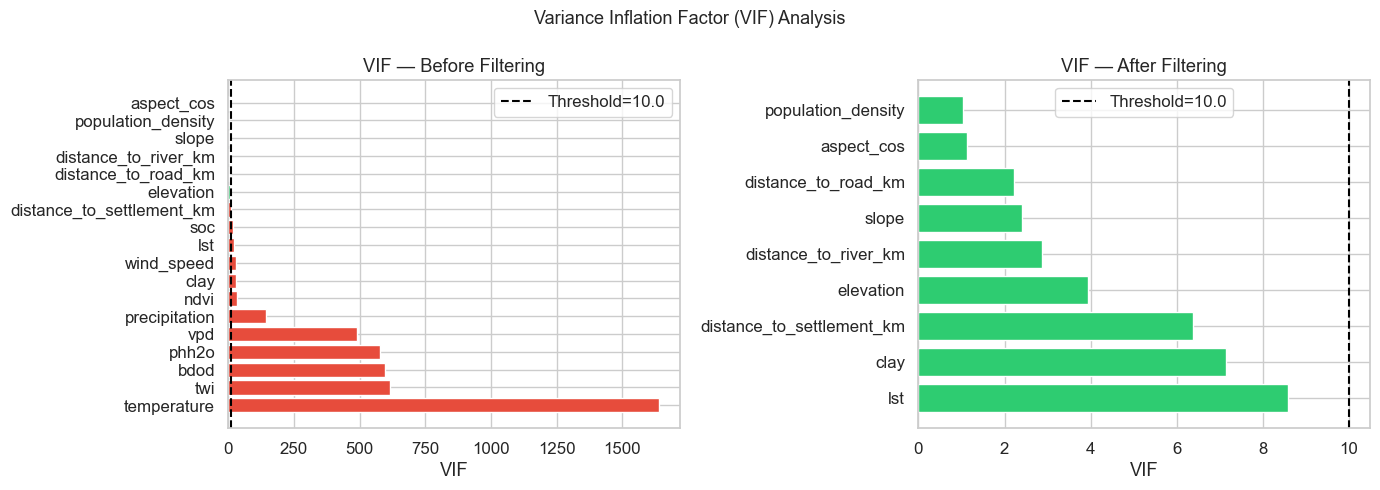

In [5]:
# Visualise VIF before / after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_before = ['#e74c3c' if v > VIF_THRESHOLD else '#2ecc71' for v in initial_vif['VIF']]
axes[0].barh(initial_vif['feature'], initial_vif['VIF'], color=colors_before)
axes[0].axvline(VIF_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={VIF_THRESHOLD}')
axes[0].set_title('VIF — Before Filtering')
axes[0].set_xlabel('VIF')
axes[0].legend()

colors_after = ['#2ecc71'] * len(final_vif)
axes[1].barh(final_vif['feature'], final_vif['VIF'], color=colors_after)
axes[1].axvline(VIF_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={VIF_THRESHOLD}')
axes[1].set_title('VIF — After Filtering')
axes[1].set_xlabel('VIF')
axes[1].legend()

plt.suptitle('Variance Inflation Factor (VIF) Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'preprocessing_vif.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pairwise Correlation Filter

In [6]:
def correlation_filter(df: pd.DataFrame, features: list, threshold: float) -> list:
    """
    Drop one feature from each pair with |r| > threshold.
    For each violating pair, drop the one with lower |correlation with label|.
    """
    corr = df[features].corr().abs()
    target_corr = df[features + ['label']].corr()['label'].abs()
    
    to_drop = set()
    pairs = []
    for i, f1 in enumerate(features):
        for f2 in features[i+1:]:
            r = corr.loc[f1, f2]
            if r > threshold:
                pairs.append((f1, f2, r))
                # drop the one less correlated with target
                drop = f1 if target_corr[f1] < target_corr[f2] else f2
                to_drop.add(drop)
                print(f'  Drop "{drop}" (r({f1},{f2})={r:.3f})')
    
    kept = [f for f in features if f not in to_drop]
    return kept, list(to_drop), pairs


print(f'Pairwise correlation filter (threshold |r| = {CORR_THRESHOLD})...')
print(f'Input features: {len(kept_features)}')
print()

# Correlation matrix before
corr_before = df[kept_features].corr()

features_after_corr, dropped_corr, high_pairs = correlation_filter(
    df, kept_features, CORR_THRESHOLD
)

print(f'\nDropped by correlation filter: {dropped_corr}')
print(f'Kept after correlation filter: {len(features_after_corr)} — {features_after_corr}')

Pairwise correlation filter (threshold |r| = 0.85)...
Input features: 9


Dropped by correlation filter: []
Kept after correlation filter: 9 — ['elevation', 'slope', 'aspect_cos', 'lst', 'population_density', 'clay', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km']


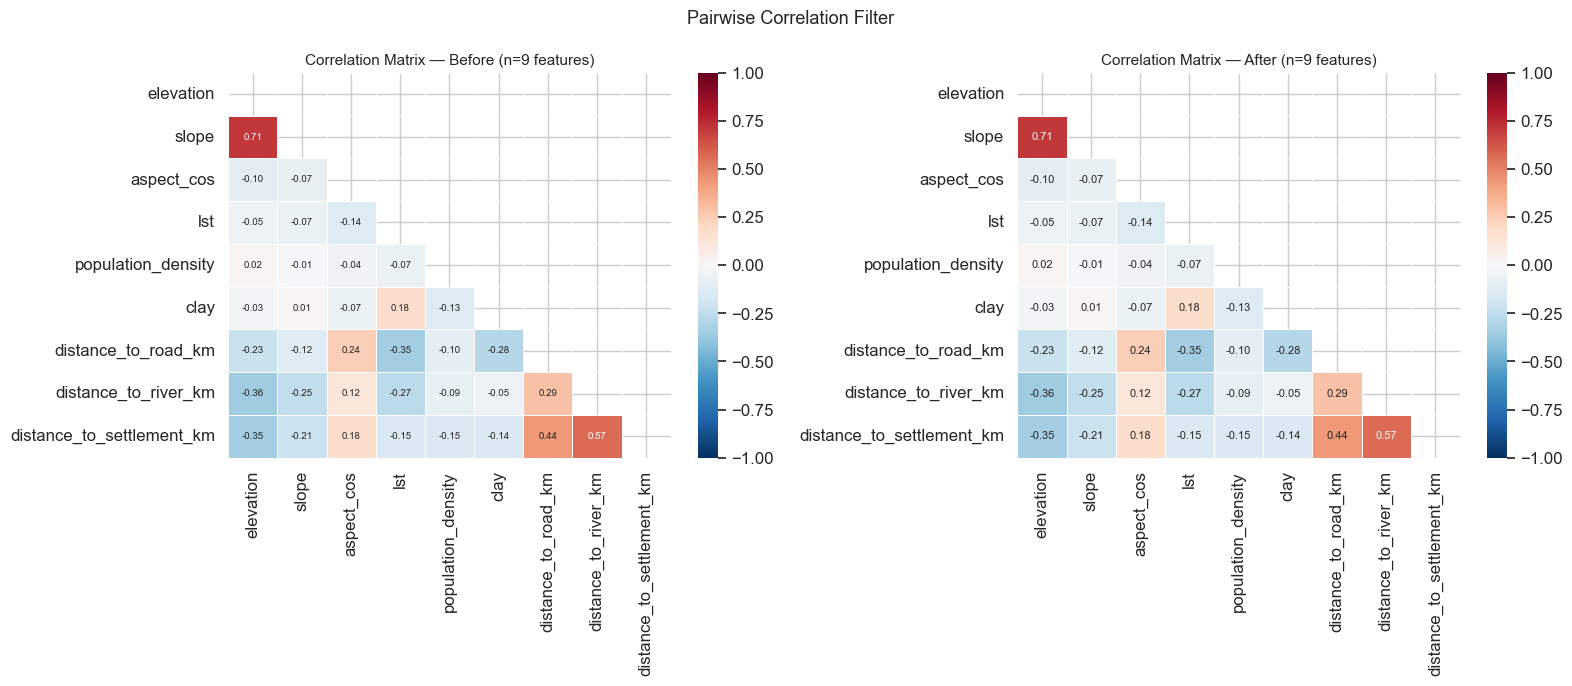

In [7]:
# Visualise correlation matrix before / after
corr_after = df[features_after_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
mask = np.triu(np.ones_like(corr_before, dtype=bool))
sns.heatmap(corr_before, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 7}, ax=axes[0])
axes[0].set_title(f'Correlation Matrix — Before (n={len(kept_features)} features)', fontsize=11)

mask2 = np.triu(np.ones_like(corr_after, dtype=bool))
sns.heatmap(corr_after, mask=mask2, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=axes[1])
axes[1].set_title(f'Correlation Matrix — After (n={len(features_after_corr)} features)', fontsize=11)

plt.suptitle('Pairwise Correlation Filter', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'preprocessing_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Final Feature Set

In [8]:
# Final selected continuous features
FINAL_CONTINUOUS = features_after_corr

print('=== FINAL FEATURE SET ===')
print(f'  Initial numeric features  : {len(initial_numeric)}')
print(f'  Dropped by VIF            : {len(dropped_vif)}  → {dropped_vif}')
print(f'  Dropped by correlation    : {len(dropped_corr)}  → {dropped_corr}')
print(f'  Final continuous features : {len(FINAL_CONTINUOUS)}')
print(f'  Categorical feature       : land_cover_class (will be one-hot encoded)')
print(f'  Other kept cols           : lat, lon, month, fire_season_flag (not used in model)')
print()
print('Final continuous features:')
for f in FINAL_CONTINUOUS:
    print(f'  - {f}')

=== FINAL FEATURE SET ===
  Initial numeric features  : 18
  Dropped by VIF            : 9  → ['temperature', 'phh2o', 'twi', 'bdod', 'vpd', 'precipitation', 'ndvi', 'soc', 'wind_speed']
  Dropped by correlation    : 0  → []
  Final continuous features : 9
  Categorical feature       : land_cover_class (will be one-hot encoded)
  Other kept cols           : lat, lon, month, fire_season_flag (not used in model)

Final continuous features:
  - elevation
  - slope
  - aspect_cos
  - lst
  - population_density
  - clay
  - distance_to_road_km
  - distance_to_river_km
  - distance_to_settlement_km


## 5. One-Hot Encode `land_cover_class`

In [9]:
print('land_cover_class value counts:')
print(df['land_cover_class'].value_counts().sort_index())

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=np.float32)
lc_array = encoder.fit_transform(df[['land_cover_class']])
lc_cols = [f'lc_{int(c)}' for c in encoder.categories_[0]]
df_lc = pd.DataFrame(lc_array, columns=lc_cols, index=df.index)

print(f'\nOne-hot encoded into {len(lc_cols)} columns: {lc_cols}')

land_cover_class value counts:
land_cover_class
20.0     13950
30.0     20457
40.0     30992
50.0       738
60.0       540
80.0       958
90.0      2096
114.0      182
116.0     1248
124.0        1
126.0     1134
Name: count, dtype: int64

One-hot encoded into 11 columns: ['lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']


## 6. StandardScaler on Continuous Features

In [10]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[FINAL_CONTINUOUS]),
    columns=FINAL_CONTINUOUS,
    index=df.index
)

print('Scaler fitted on continuous features.')
print(f'  Features: {FINAL_CONTINUOUS}')
print(f'  Mean (should be ≈0):  {df_scaled.mean().round(6).values}')
print(f'  Std  (should be ≈1):  {df_scaled.std().round(6).values}')

Scaler fitted on continuous features.
  Features: ['elevation', 'slope', 'aspect_cos', 'lst', 'population_density', 'clay', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km']
  Mean (should be ≈0):  [ 0. -0. -0.  0. -0.  0. -0.  0.  0.]
  Std  (should be ≈1):  [1.000007 1.000007 1.000007 1.000007 1.000007 1.000007 1.000007 1.000007
 1.000007]


## 7. Assemble Final Dataset & Train/Test Split

In [11]:
# Assemble model-ready dataframe
df_model = pd.concat([
    df[['lat', 'lon', 'label']].reset_index(drop=True),
    df_scaled.reset_index(drop=True),
    df_lc.reset_index(drop=True)
], axis=1)

MODEL_FEATURES = FINAL_CONTINUOUS + lc_cols

print(f'Model-ready dataframe shape: {df_model.shape}')
print(f'Total model features: {len(MODEL_FEATURES)}')
print(f'  Continuous (scaled): {len(FINAL_CONTINUOUS)}')
print(f'  One-hot land cover : {len(lc_cols)}')
df_model.head(3)

Model-ready dataframe shape: (72296, 23)
Total model features: 20
  Continuous (scaled): 9
  One-hot land cover : 11


,lat,lon,label,elevation,slope,aspect_cos,lst,population_density,clay,distance_to_road_km,...,lc_30,lc_40,lc_50,lc_60,lc_80,lc_90,lc_114,lc_116,lc_124,lc_126
0,-33.719648,-64.681616,0,-0.019517,-0.303936,-1.484956,0.522971,-0.123474,-0.910364,-0.790983,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-30.267707,-64.798635,0,-0.364886,-0.294704,1.285505,0.495883,-0.116978,-0.142166,0.476935,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-33.632001,-64.483284,0,-0.118598,-0.346687,-1.160945,0.368962,-0.122253,-0.823632,-0.248331,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# Stratified 70/30 split
X = df_model[MODEL_FEATURES]
y = df_model['label']
meta = df_model[['lat', 'lon']]

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, meta, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

train_df = pd.concat([meta_train.reset_index(drop=True),
                       y_train.reset_index(drop=True),
                       X_train.reset_index(drop=True)], axis=1)
test_df  = pd.concat([meta_test.reset_index(drop=True),
                       y_test.reset_index(drop=True),
                       X_test.reset_index(drop=True)], axis=1)

print('=== TRAIN / TEST SPLIT ===')
print(f'  Train: {len(train_df):,} rows  |  fire={y_train.sum():,}  no-fire={(y_train==0).sum():,}  ratio={y_train.mean():.3f}')
print(f'  Test : {len(test_df):,} rows  |  fire={y_test.sum():,}   no-fire={(y_test==0).sum():,}   ratio={y_test.mean():.3f}')
print(f'  Stratification OK: train {y_train.mean():.4f} ≈ test {y_test.mean():.4f}')

=== TRAIN / TEST SPLIT ===
  Train: 50,607 rows  |  fire=25,304  no-fire=25,303  ratio=0.500
  Test : 21,689 rows  |  fire=10,844   no-fire=10,845   ratio=0.500
  Stratification OK: train 0.5000 ≈ test 0.5000


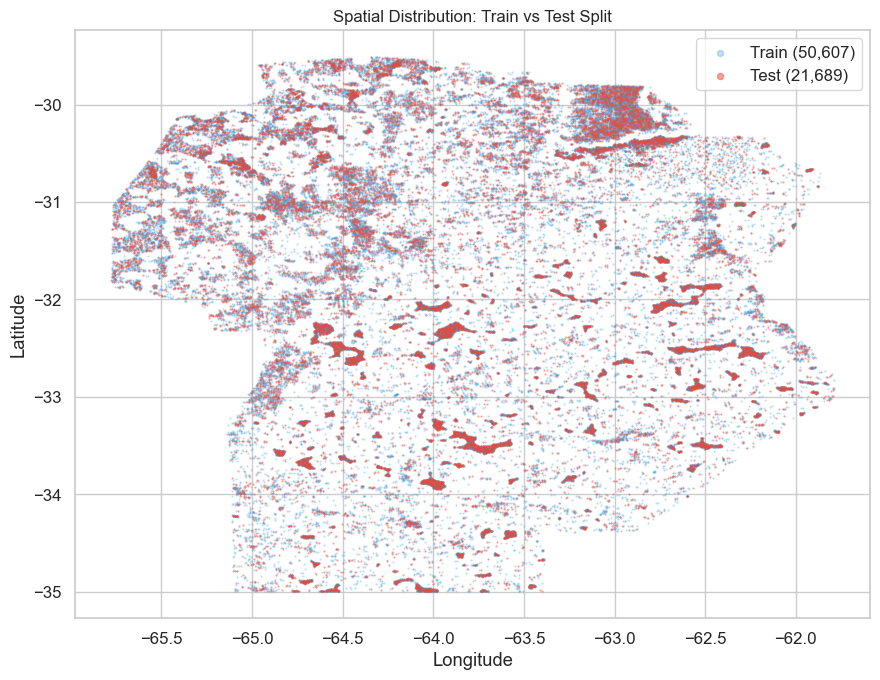

In [13]:
# Spatial distribution of train vs test (should be well mixed)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(meta_train['lon'], meta_train['lat'], s=0.3, c='#3498db', alpha=0.3, label=f'Train ({len(train_df):,})')
ax.scatter(meta_test['lon'],  meta_test['lat'],  s=0.3, c='#e74c3c', alpha=0.5, label=f'Test ({len(test_df):,})')
ax.set_title('Spatial Distribution: Train vs Test Split', fontsize=12)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(markerscale=8)
plt.tight_layout()
plt.savefig(OUTPUTS / 'preprocessing_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save All Outputs

In [14]:
# Save CSVs
train_df.to_csv(PROCESSED / 'train.csv', index=False)
test_df.to_csv(PROCESSED  / 'test.csv',  index=False)
print(f'Saved train.csv ({train_df.shape}) and test.csv ({test_df.shape})')

# Save scaler
with open(PROCESSED / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved scaler.pkl')

# Save encoder
with open(PROCESSED / 'encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print('Saved encoder.pkl')

# Save selected features list (for inference)
feature_meta = {
    'continuous_features': FINAL_CONTINUOUS,
    'landcover_ohe_features': lc_cols,
    'all_model_features': MODEL_FEATURES,
    'dropped_vif': dropped_vif,
    'dropped_correlation': dropped_corr,
    'vif_threshold': VIF_THRESHOLD,
    'corr_threshold': CORR_THRESHOLD,
    'pop_density_impute_median': float(pop_median)
}
with open(PROCESSED / 'selected_features.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
print('Saved selected_features.json')

Saved train.csv ((50607, 23)) and test.csv ((21689, 23))
Saved scaler.pkl
Saved encoder.pkl
Saved selected_features.json


## 9. Verification Summary

In [15]:
print('=== PHASE 3 VERIFICATION ===')

# 1. No NaN
assert train_df.isnull().sum().sum() == 0, 'NaN in train'
assert test_df.isnull().sum().sum()  == 0, 'NaN in test'
print('  [OK] No NaN in train/test')

# 2. VIF all < threshold
assert final_vif['VIF'].max() <= VIF_THRESHOLD
print(f'  [OK] All VIF <= {VIF_THRESHOLD} (max={final_vif["VIF"].max():.2f})')

# 3. No pairwise |r| > threshold in final features
corr_arr = df[FINAL_CONTINUOUS].corr().abs().to_numpy().copy()
np.fill_diagonal(corr_arr, 0)
max_corr = corr_arr.max()
assert max_corr <= CORR_THRESHOLD, f'Correlation violation: {max_corr:.3f}'
print(f'  [OK] Max pairwise |r| in final features = {max_corr:.3f} <= {CORR_THRESHOLD}')

# 4. Class balance preserved
assert abs(y_train.mean() - y_test.mean()) < 0.01
print(f'  [OK] Stratification preserved (train={y_train.mean():.4f}, test={y_test.mean():.4f})')

# 5. Expected split sizes
expected_train = int(len(df) * (1 - TEST_SIZE))
expected_test  = len(df) - expected_train
print(f'  [OK] Split sizes: train={len(train_df):,}  test={len(test_df):,}')

# 6. Files exist
for fname in ['train.csv', 'test.csv', 'scaler.pkl', 'encoder.pkl', 'selected_features.json']:
    assert (PROCESSED / fname).exists()
print('  [OK] All output files saved')

print()
print('=== FINAL FEATURE SUMMARY ===')
print(f'  {len(FINAL_CONTINUOUS)} continuous features (scaled):')
for f in FINAL_CONTINUOUS:
    print(f'    - {f}')
print(f'  {len(lc_cols)} one-hot land cover features:')
print(f'    {lc_cols}')
print(f'  Total model input dim: {len(MODEL_FEATURES)}')

=== PHASE 3 VERIFICATION ===
  [OK] No NaN in train/test
  [OK] All VIF <= 10.0 (max=8.59)
  [OK] Max pairwise |r| in final features = 0.710 <= 0.85
  [OK] Stratification preserved (train=0.5000, test=0.5000)
  [OK] Split sizes: train=50,607  test=21,689
  [OK] All output files saved

=== FINAL FEATURE SUMMARY ===
  9 continuous features (scaled):
    - elevation
    - slope
    - aspect_cos
    - lst
    - population_density
    - clay
    - distance_to_road_km
    - distance_to_river_km
    - distance_to_settlement_km
  11 one-hot land cover features:
    ['lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']
  Total model input dim: 20
